# Phần 1: Bài toán Hồi quy
**Dataset:** California Housing Prices (Kaggle / StatLib)  

---

## Mục lục
- [B. EDA & Tiền xử lý Dữ liệu](#b)
  - [B.1 Load & Mô tả dataset](#b1)
  - [B.2 Xử lý Missing Values](#b2)
  - [B.3 Phân bố biến mục tiêu](#b3)
  - [B.4 Ma trận tương quan & Scatter plots](#b4)
  - [B.5 Phát hiện Outliers](#b5)
  - [B.6 Feature Engineering & Encode Categorical](#b6)
  - [B.7 Stratified Train/Val/Test Split](#b7)
  - [B.8 Chuẩn hóa (StandardScaler)](#b8)
  - [B.9 Kiểm tra phân phối sau split](#b9)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

# Import toàn bộ helper functions từ utils.py
from utils import *

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = '../../data/housing.csv' 
print('Import thành công!')

Import thành công!


---
<a id='b'></a>
## B. Phân tích Khám phá & Tiền xử lý Dữ liệu

Phần này thực hiện đầy đủ pipeline EDA trước khi huấn luyện mô hình, bao gồm:
phân tích thống kê mô tả, phát hiện và xử lý missing values, phát hiện outliers,
phân tích tương quan, feature engineering, và chia dữ liệu train/val/test.

<a id='b1'></a>
### B.1 Load & Mô tả Dataset

**Dataset:** California Housing Prices, thu thập từ Census 1990 của California.  
Mỗi mẫu đại diện cho một **block group** (đơn vị địa lý nhỏ nhất của census,
thường có 600–3000 người).

| Feature | Kiểu | Mô tả |
|---|---|---|
| `longitude` | float | Kinh độ của block group |
| `latitude` | float | Vĩ độ của block group |
| `housing_median_age` | float | Tuổi trung vị của nhà trong block group |
| `total_rooms` | float | Tổng số phòng trong block group |
| `total_bedrooms` | float | Tổng số phòng ngủ (có NaN) |
| `population` | float | Dân số block group |
| `households` | float | Số hộ gia đình |
| `median_income` | float | Thu nhập trung vị (đơn vị: 10,000 USD) |
| `median_house_value` | float | **Target** — Giá nhà trung vị ($) |
| `ocean_proximity` | object | Khoảng cách tới biển (5 nhóm) |


In [2]:
df = load_data(DATA_PATH)

  Dataset loaded: ../../data/housing.csv
  Số mẫu (rows)     : 20,640
  Số features (cols): 10

  Kiểu dữ liệu:
    longitude                           float64     
    latitude                            float64     
    housing_median_age                  float64     
    total_rooms                         float64     
    total_bedrooms                      float64       ← 207 NaN
    population                          float64     
    households                          float64     
    median_income                       float64     
    median_house_value                  float64     
    ocean_proximity                     object      


In [3]:
# Thống kê mô tả mở rộng (thêm skewness & kurtosis)
stats_df = describe_stats(df)
stats_df

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
longitude,20640.0,-119.570,2.004,-124.35,-121.800,-118.490,-118.010,-114.31,-0.298,-1.330
latitude,20640.0,35.632,2.136,32.54,33.930,34.260,37.710,41.95,0.466,-1.118
housing_median_age,20640.0,28.639,12.586,1.00,18.000,29.000,37.000,52.00,0.060,-0.801
total_rooms,20640.0,2635.763,2181.615,2.00,1447.750,2127.000,3148.000,39320.00,4.147,32.631
total_bedrooms,20433.0,537.871,421.385,1.00,296.000,435.000,647.000,6445.00,3.460,21.986
population,20640.0,1425.477,1132.462,3.00,787.000,1166.000,1725.000,35682.00,4.936,73.553
households,20640.0,499.540,382.330,1.00,280.000,409.000,605.000,6082.00,3.410,22.058
median_income,20640.0,3.871,1.900,0.50,2.563,3.535,4.743,15.00,1.647,4.953
median_house_value,20640.0,206855.817,115395.616,14999.00,119600.000,179700.000,264725.000,500001.00,0.978,0.328


**Nhận xét:**
- `total_rooms`, `total_bedrooms`, `population`, `households` có **skewness cao** (> 2),
  phân phối lệch phải mạnh — cần lưu ý khi dùng các phương pháp giả thiết Gaussian.
- `housing_median_age` bị **cap ở 52** (max = 52), tương tự `median_house_value` bị cap ở $500,000.
- `median_income` không có đơn vị USD thông thường mà đã được scale (đơn vị ≈ $10,000).

<a id='b2'></a>
### B.2 Xử lý Missing Values

Theo thống kê, chỉ có `total_bedrooms` chứa giá trị NaN.
Ta chọn **impute bằng median** vì:
1. Phân phối của `total_bedrooms` lệch phải mạnh → mean bị kéo bởi outliers.
2. Median robust hơn với outliers trong trường hợp này.

In [4]:
# Báo cáo missing values
_ = report_missing(df)

                count  percent (%)
total_bedrooms    207          1.0


In [5]:
# Impute total_bedrooms bằng median
df = impute_missing(df, col='total_bedrooms', strategy='median')

# Xác nhận không còn NaN
print(f"Missing sau impute: {df.isnull().sum().sum()}")

Imputed 'total_bedrooms': 207 NaN → median = 435.00
Missing sau impute: 0


<a id='b3'></a>
### B.3 Phân bố Biến Mục tiêu (`median_house_value`)

Trước khi xây dựng mô hình, cần hiểu rõ phân bố của biến mục tiêu.
Đây là bước quan trọng để phát hiện các vấn đề như:
- **Ceiling effect**: giá trị bị giới hạn cứng
- **Heavy-tailed distribution**: ảnh hưởng đến assumption của OLS
- **Multimodality**: có thể cần phân tách dữ liệu

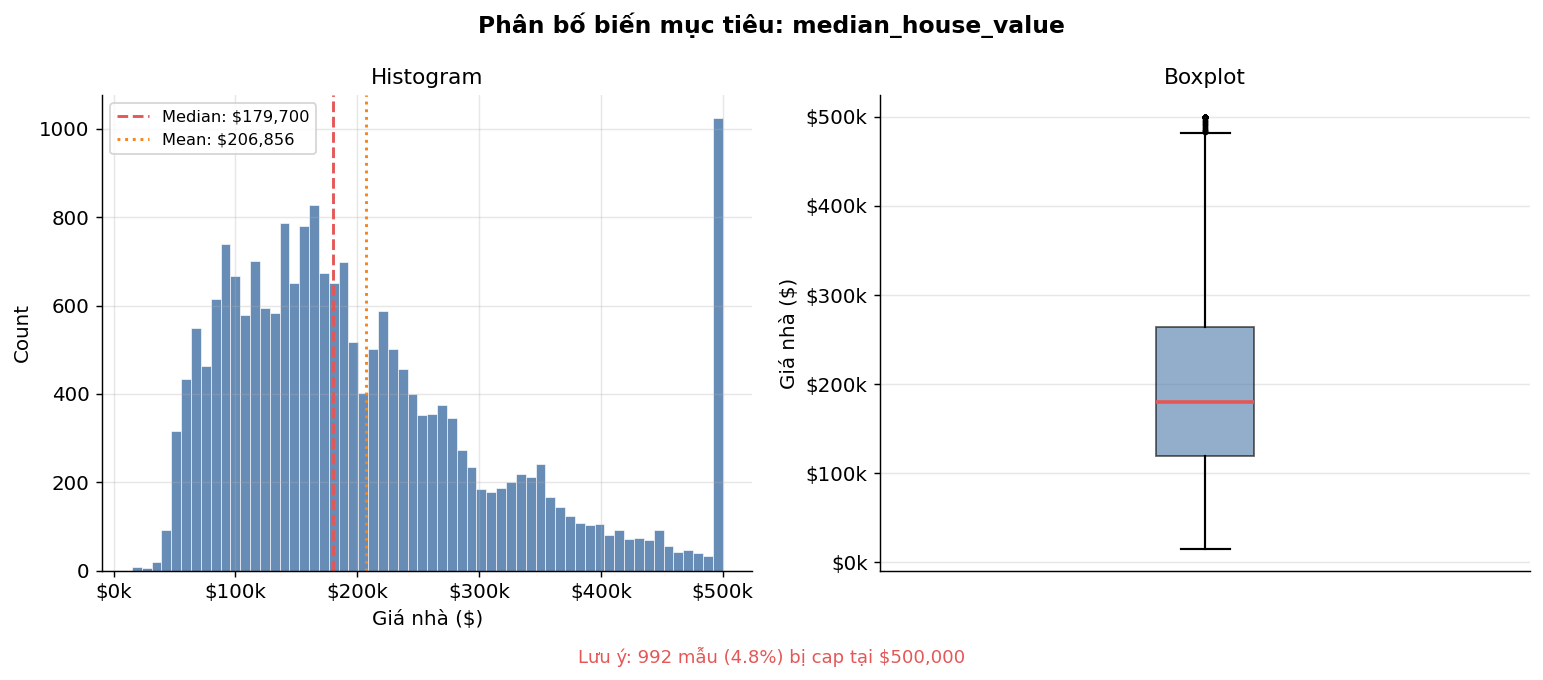


Thống kê median_house_value:
count     20640.00
mean     206855.82
std      115395.62
min       14999.00
25%      119600.00
50%      179700.00
75%      264725.00
max      500001.00


In [6]:
plot_target_distribution(df, target='median_house_value')

**Nhận xét:**
- Phân phối lệch phải, với đuôi dài về phía giá trị cao.
- Có **spike rõ rệt tại \$500,000** do **ceiling effect** — Census đặt cap tại mức này.
  Các mẫu này (~5%) không phản ánh giá trị thực → có thể ảnh hưởng đến mô hình.
- Mean (≈ \$206k) > Median (≈ \$179k), xác nhận phân phối lệch phải.
- **Hướng xử lý:** giữ lại nhưng ghi chú; có thể thử log-transform target ở phần C.

<a id='b4'></a>
### B.4 Ma trận Tương quan & Scatter Plots

Phân tích tương quan giúp:
1. Xác định features có **tương quan cao với target** → ưu tiên trong mô hình.
2. Phát hiện **multicollinearity** giữa các features → ảnh hưởng đến OLS.
3. Định hướng **feature engineering** (tạo ratio features).

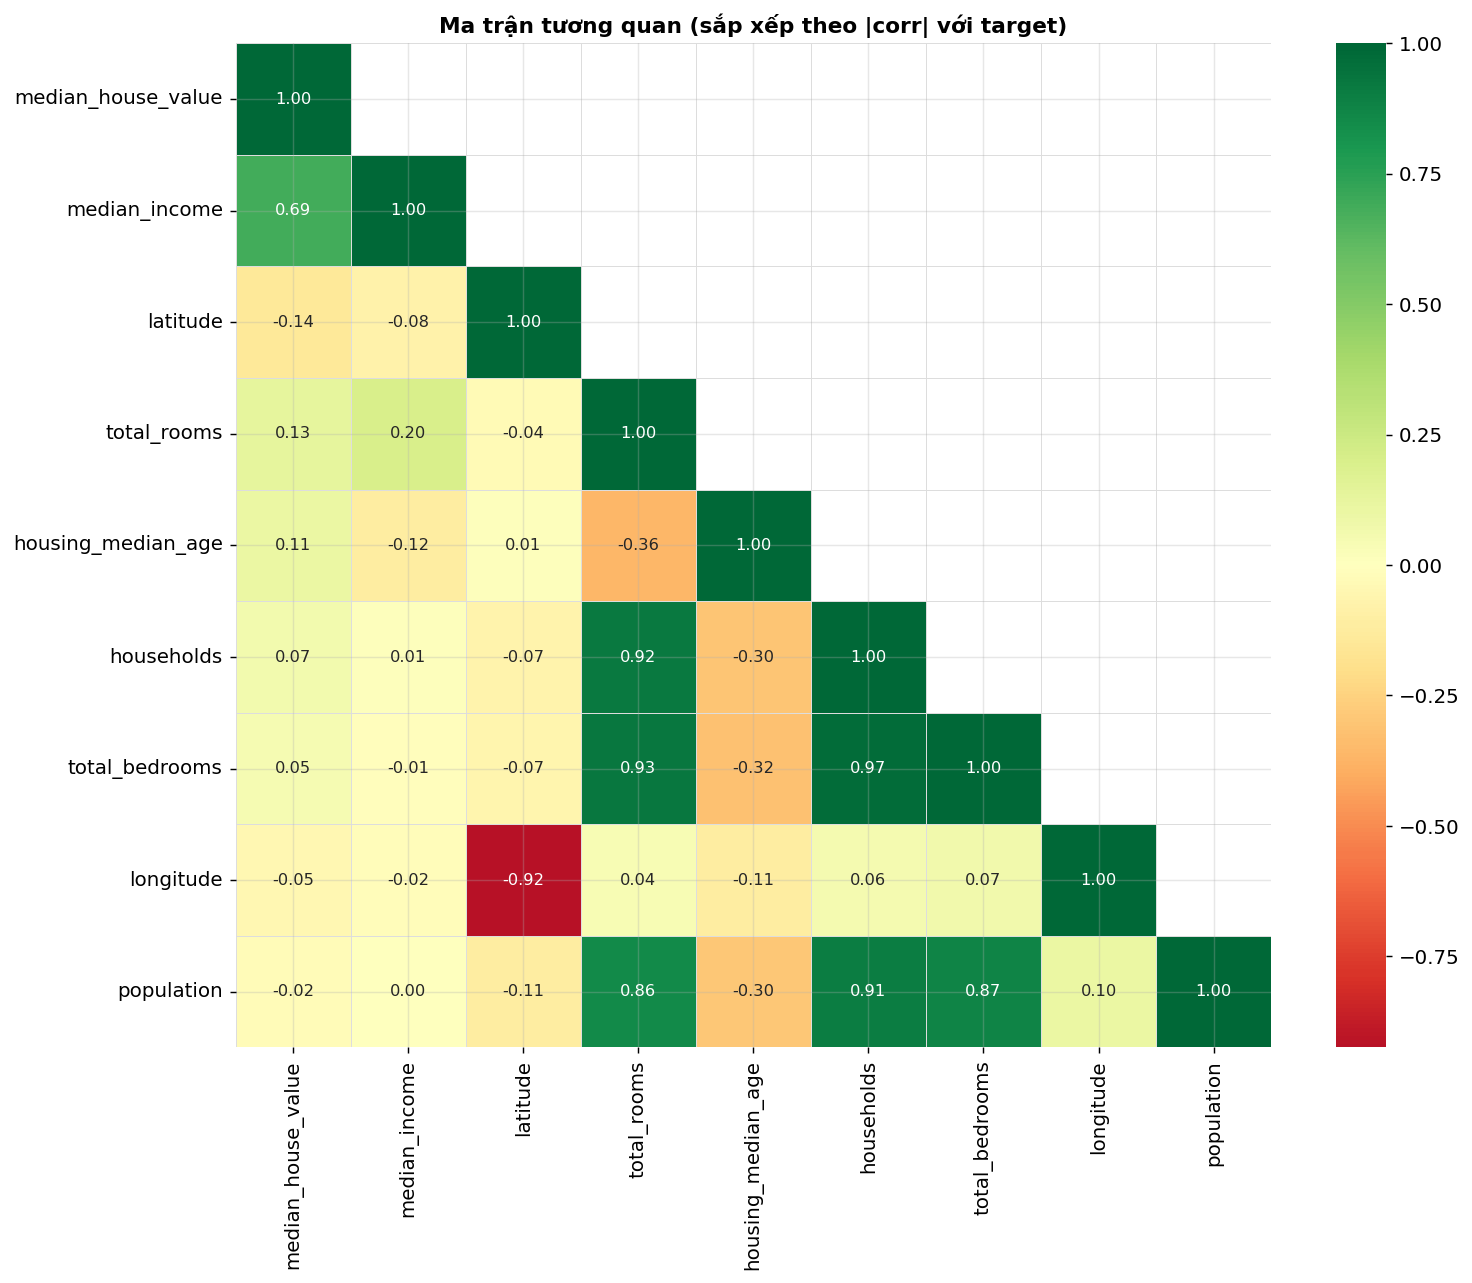


Tương quan với 'median_house_value':
median_income         0.688
latitude             -0.144
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.049
longitude            -0.046
population           -0.025


In [7]:
target_corr = plot_correlation_matrix(df, target='median_house_value')

Top 6 features tương quan với target: ['median_income', 'latitude', 'total_rooms', 'housing_median_age', 'households', 'total_bedrooms']


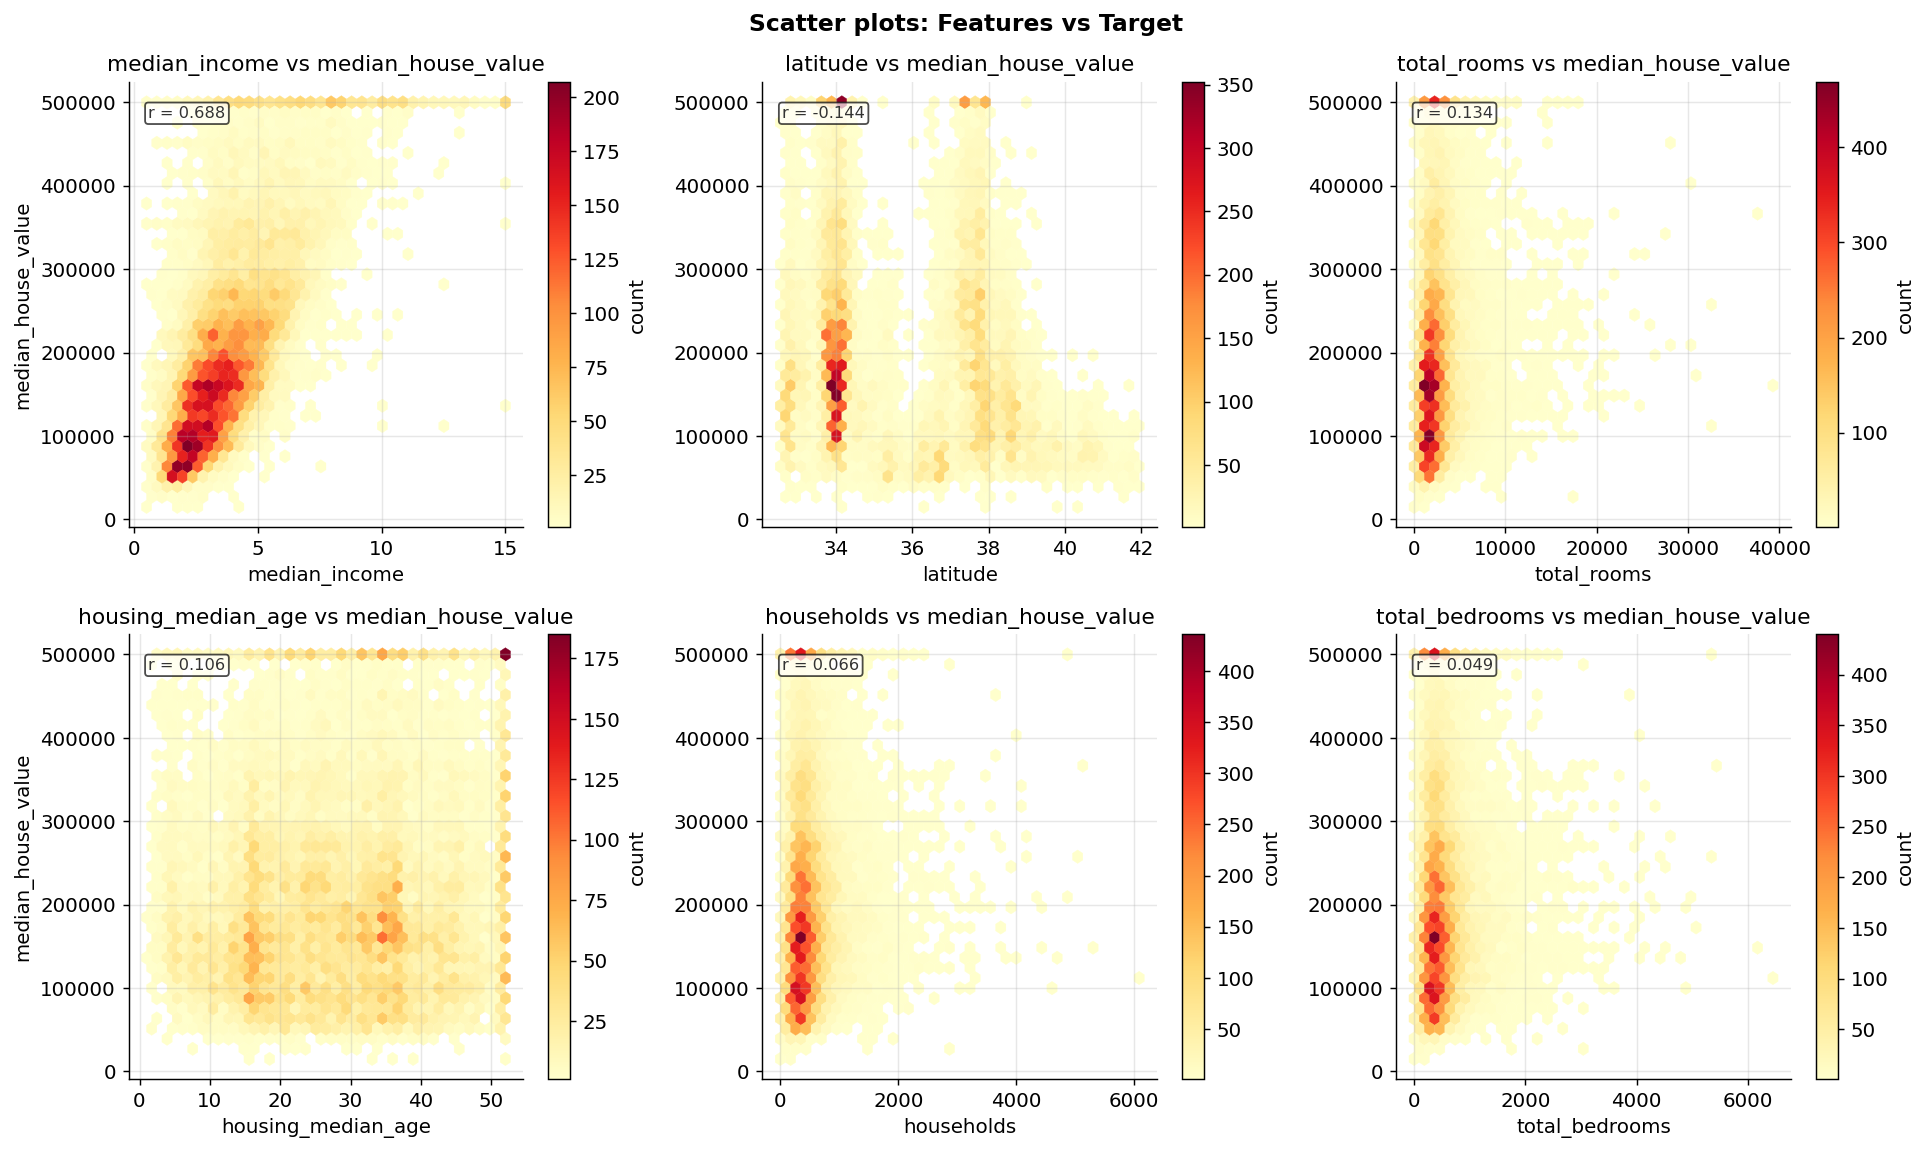

In [8]:
# Scatter plots các features quan trọng nhất với target
top_features = target_corr.abs().sort_values(ascending=False).head(6).index.tolist()
print(f"Top 6 features tương quan với target: {top_features}")
plot_scatter_features(df, features=top_features, target='median_house_value')

**Nhận xét:**
- `median_income` có tương quan cao nhất với target (r ≈ 0.69) — đây là predictor quan trọng nhất.
- `total_rooms`, `total_bedrooms`, `households`, `population` tương quan cao với nhau
  (multicollinearity) → Ridge/Lasso sẽ xử lý tốt hơn OLS thuần túy.
- `latitude` và `longitude` có tương quan âm — phản ánh hiệu ứng địa lý
  (vùng ven biển phía nam giá cao hơn).

<a id='b5'></a>
### B.5 Phát hiện Outliers

Hai phương pháp được sử dụng:

- **IQR method:** điểm nằm ngoài $[Q_1 - 1.5 \cdot IQR,\ Q_3 + 1.5 \cdot IQR]$  
  Phù hợp hơn cho phân phối lệch, không giả thiết Gaussian.

- **Z-score method:** điểm có $|z| > 3$ (nằm ngoài 3 độ lệch chuẩn)  
  Giả thiết phân phối Gaussian, nhạy hơn với heavy-tailed distributions.

Ta áp dụng trên các biến **tổng** (`total_rooms`, `population`, v.v.) vì chúng phụ thuộc vào
kích thước block group → phân phối lệch mạnh.

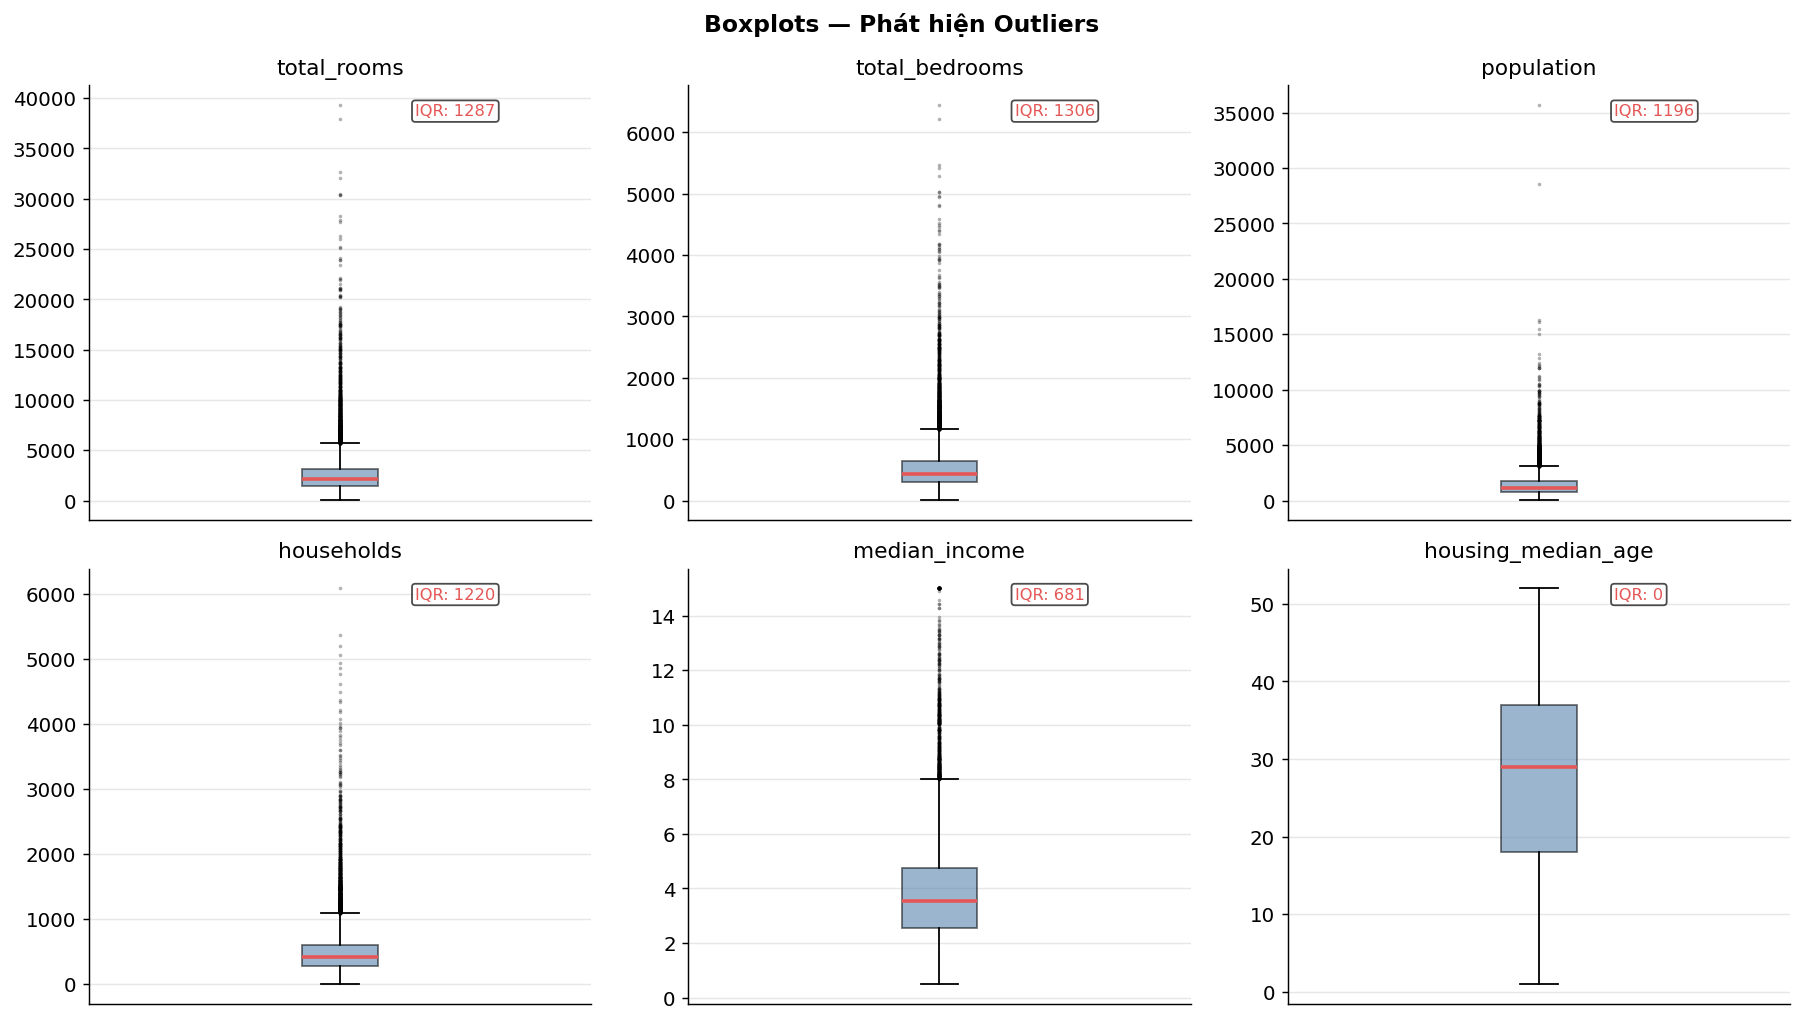

,Feature,IQR outliers,IQR (%),Z-score outliers,Z-score (%)
0,total_rooms,1287,6.24,373,1.81
1,total_bedrooms,1306,6.33,375,1.82
2,population,1196,5.79,342,1.66
3,households,1220,5.91,363,1.76
4,median_income,681,3.30,345,1.67
5,housing_median_age,0,0.00,0,0.00


In [9]:
outlier_report = report_outliers(df)
outlier_report

**Nhận xét:**
- `total_rooms`, `total_bedrooms`, `population`, `households` có outliers theo IQR 
  (~5–6%), phản ánh sự chênh lệch lớn về quy mô giữa các block group.
- Z-score cho kết quả ít outliers hơn vì phân phối không Gaussian (không thỏa mãn giả thiết).
- **Quyết định:** Giữ lại outliers vì đây là dữ liệu thực tế hợp lệ, không phải lỗi đo lường.
  Regularization (Ridge/Lasso) sẽ giúp giảm ảnh hưởng của chúng.

<a id='b6'></a>
### B.6 Feature Engineering & Encode Categorical

**Ratio features:** Các biến tổng (`total_rooms`, `population`) phụ thuộc vào kích thước block group,
nên ít có ý nghĩa trực tiếp. Tạo thêm ratio features có ý nghĩa thực tế hơn:

$$\text{rooms\_per\_household} = \frac{\text{total\_rooms}}{\text{households}}$$

$$\text{bedrooms\_per\_room} = \frac{\text{total\_bedrooms}}{\text{total\_rooms}}$$

$$\text{population\_per\_household} = \frac{\text{population}}{\text{households}}$$

**One-hot encoding:** `ocean_proximity` là biến categorical với 5 giá trị không có thứ tự
→ cần encode thành các biến dummy (không dùng `drop_first` để giữ khả năng giải thích).

In [10]:
# Tạo ratio features
df = engineer_features(df)

Đã tạo 3 ratio features:
  rooms_per_household     = total_rooms / households
  bedrooms_per_room       = total_bedrooms / total_rooms
  population_per_household = population / households


In [11]:
# Kiểm tra tương quan của features mới với target
new_features = ['rooms_per_household', 'bedrooms_per_room', 'population_per_household']
for f in new_features:
    from scipy.stats import pearsonr
    r, p = pearsonr(df[f], df['median_house_value'])
    print(f"  {f:<35} r = {r:+.4f}  (p = {p:.2e})")

  rooms_per_household                 r = +0.1519  (p = 7.57e-107)
  bedrooms_per_room                   r = -0.2333  (p = 3.62e-253)
  population_per_household            r = -0.0237  (p = 6.48e-04)


In [12]:
# One-hot encode ocean_proximity
df = encode_categorical(df, col='ocean_proximity')
print(f"\nShape sau encoding: {df.shape}")
print(f"Columns: {df.columns.tolist()}")


Giá trị của 'ocean_proximity':
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5

Sau one-hot encode: 17 columns

Shape sau encoding: (20640, 17)
Columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


**Nhận xét:**
- `rooms_per_household` có tương quan **dương** với target (nhà nhiều phòng hơn thường đắt hơn).
- `bedrooms_per_room` có tương quan **âm** (tỷ lệ phòng ngủ cao → nhà chất lượng thấp hơn).
- `population_per_household` có tương quan **âm** (hộ đông người → khu vực thu nhập thấp hơn).
- Các ratio features này sẽ được dùng làm **basis tự chọn** trong phần E.

<a id='b7'></a>
### B.7 Stratified Train / Val / Test Split

**Tại sao stratified?**  
`median_income` là predictor quan trọng nhất và có phân phối không đều.
Nếu chia ngẫu nhiên, một tập có thể thiếu representation của nhóm thu nhập cao/thấp.
Ta chia `median_income` thành 5 nhóm và dùng `StratifiedShuffleSplit` để đảm bảo
tỷ lệ mỗi nhóm **nhất quán** trong cả 3 tập.

**Tỷ lệ:** 70% train / 10% val / 20% test

In [13]:
X_train, X_val, X_test, y_train, y_val, y_test, feature_names = stratified_split(
    df,
    target='median_house_value',
    test_size=0.2,
    val_size=0.1,
    random_state=RANDOM_STATE
)

print(f"\nFeatures ({len(feature_names)}):")
for i, f in enumerate(feature_names):
    print(f"  [{i:>2}] {f}")


  Train : 14,448  (70.0%)
  Val   :  2,064  (10.0%)
  Test  :  4,128  (20.0%)
  Total : 20,640
  Features: 16

Features (16):
  [ 0] longitude
  [ 1] latitude
  [ 2] housing_median_age
  [ 3] total_rooms
  [ 4] total_bedrooms
  [ 5] population
  [ 6] households
  [ 7] median_income
  [ 8] rooms_per_household
  [ 9] bedrooms_per_room
  [10] population_per_household
  [11] ocean_proximity_<1H OCEAN
  [12] ocean_proximity_INLAND
  [13] ocean_proximity_ISLAND
  [14] ocean_proximity_NEAR BAY
  [15] ocean_proximity_NEAR OCEAN


<a id='b8'></a>
### B.8 Chuẩn hóa Features (StandardScaler)

**Tại sao cần chuẩn hóa?**
- Các features có **đơn vị khác nhau**: `total_rooms` (hàng nghìn) vs `latitude` (32–38).
- OLS với Normal Equations không yêu cầu scale, nhưng **Gradient Descent** và
  **Regularization (Ridge/Lasso)** rất nhạy với scale của features.
- Ridge và Lasso phạt theo $\|\mathbf{w}\|^2$ hoặc $\|\mathbf{w}\|_1$:
  nếu không scale, features có giá trị lớn sẽ bị phạt nặng hơn một cách không công bằng.

**Quy tắc quan trọng:** Scaler chỉ được **fit trên train set**,
sau đó **transform** val và test. Không được fit trên val/test để tránh **data leakage**.

In [14]:
X_train_s, X_val_s, X_test_s, scaler = scale_features(X_train, X_val, X_test)

print(f"\nSau scaling:")
print(f"  X_train : {X_train_s.shape}")
print(f"  X_val   : {X_val_s.shape}")
print(f"  X_test  : {X_test_s.shape}")

StandardScaler fitted trên train set.
  Mean (train) ≈ -0.000000  (expected ~0)
  Std  (train) ≈ 1.000000   (expected ~1)

Sau scaling:
  X_train : (14448, 16)
  X_val   : (2064, 16)
  X_test  : (4128, 16)


<a id='b9'></a>
### B.9 Kiểm tra Phân phối sau Split

Xác nhận rằng stratification đã đảm bảo phân phối target nhất quán
giữa 3 tập dữ liệu (không bị bias do quá trình chia).

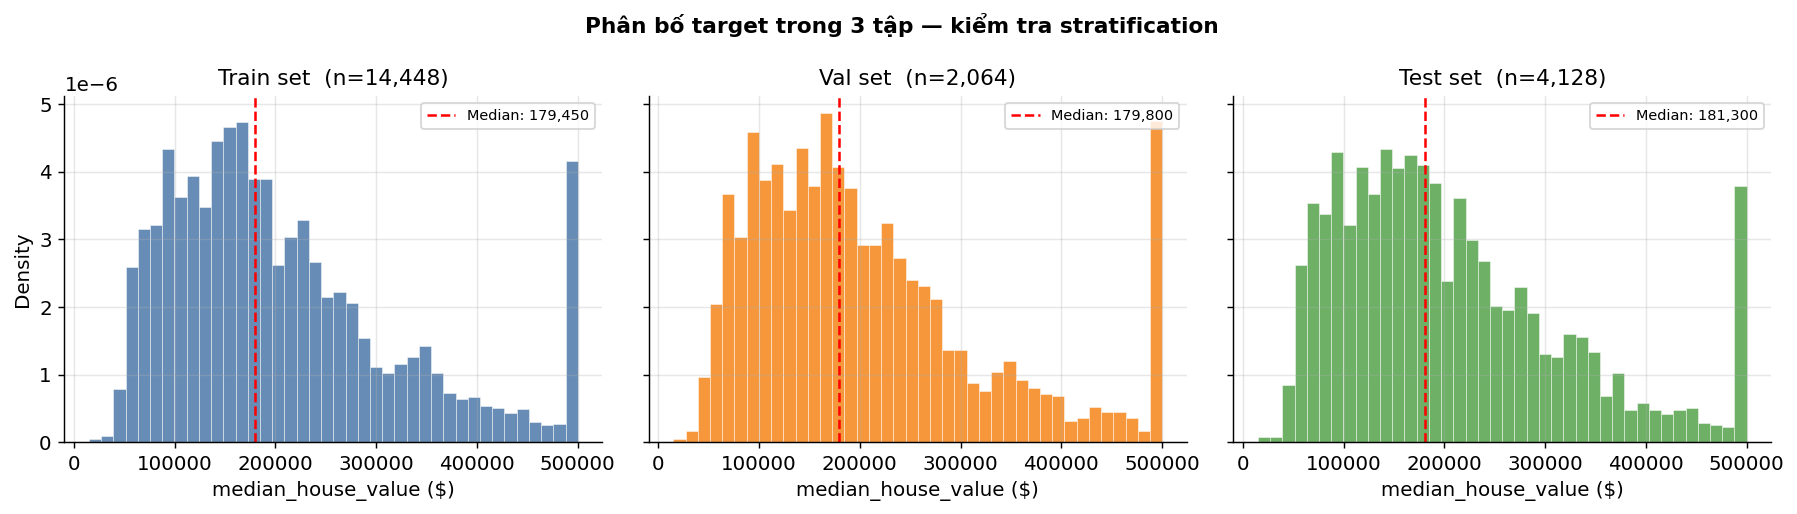

In [15]:
plot_split_distribution(y_train, y_val, y_test, target='median_house_value')

In [16]:
# So sánh thống kê cơ bản giữa 3 tập
summary = pd.DataFrame({
    'Train': pd.Series(y_train).describe(),
    'Val'  : pd.Series(y_val).describe(),
    'Test' : pd.Series(y_test).describe(),
}).round(2)
summary

,Train,Val,Test
count,14448.00,2064.00,4128.00
mean,206969.70,207254.66,206257.80
std,115435.19,117575.24,114176.65
min,14999.00,14999.00,14999.00
25%,120000.00,117575.00,118900.00
50%,179450.00,179800.00,181300.00
75%,264100.00,262100.00,268850.00
max,500001.00,500001.00,500001.00


**Nhận xét:** Mean, median, std của 3 tập xấp xỉ nhau → stratification thành công.

---

## Tổng kết Phần B

| Bước | Kết quả |
|---|---|
| Missing values | 207 NaN trong `total_bedrooms` → impute bằng median |
| Outliers | Giữ lại — dữ liệu thực tế hợp lệ |
| Feature engineering | +3 ratio features, one-hot encode `ocean_proximity` (5→5 dummy cols) |
| Tổng features | 16 features sau encoding |
| Split | 14,448 train / 2,064 val / 4,128 test (stratified) |
| Scaling | StandardScaler fit trên train only |

**Dữ liệu sẵn sàng cho Phần C (Linear Regression):**
- `X_train_s`, `X_val_s`, `X_test_s` — đã scale
- `X_train`, `X_val`, `X_test` — chưa scale (dùng cho Normal Equations)
- `y_train`, `y_val`, `y_test`
- `scaler`, `feature_names`